# Import required libraries

In [1]:
import cv2
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, average_precision_score, f1_score, precision_score, recall_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import  Dropout, GlobalAveragePooling2D, Dense, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
#import ResNet
from tensorflow.keras.applications import ResNet50

c:\Users\Nigel\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
# Paths to your data folders
train_dir = r"C:\Users\Nigel\Downloads\fer2013\train"
test_dir  = r"C:\Users\Nigel\Downloads\fer2013\test"

In [ ]:
def Classes_Count( path, name):
    Classes_Dict = {}
    
    for Class in os.listdir(path):
        
        Full_Path = os.path.join(path, Class)
        Classes_Dict[Class] = len(os.listdir(Full_Path))
        
    df = pd.DataFrame(Classes_Dict, index=[name])
    
    return df

Train_Count = Classes_Count(train_dir,"train").transpose().sort_values(by="train", ascending=False)
Test_Count = Classes_Count(test_dir, 'test').transpose().sort_values(by="test", ascending=False)

In [4]:
pd.concat([Train_Count,Test_Count] , axis=1)

,train,test
happy,7215,1774
neutral,4965,1233
sad,4830,1247
fear,4097,1024
angry,3995,958
surprise,3171,831
disgust,436,111


<Axes: >

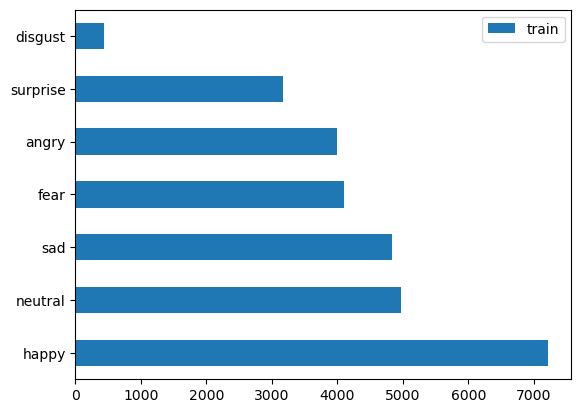

In [5]:
Train_Count.plot(kind='barh')

<Axes: >

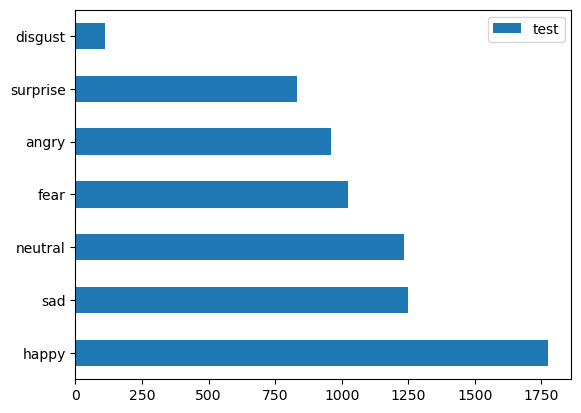

In [6]:
Test_Count.plot(kind='barh')

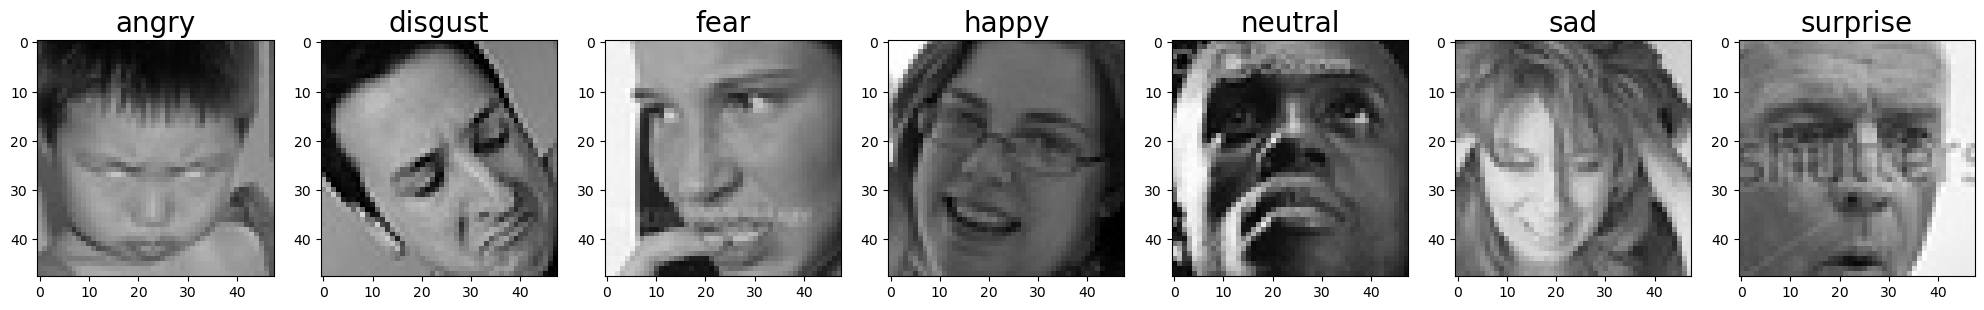

In [7]:
plt.style.use('default')
plt.figure(figsize = (25, 8))
image_count = 1
BASE_URL = r"C:\Users\Nigel\Downloads\fer2013\train"

for directory in os.listdir(BASE_URL):
    if directory[0] != '.':
        class_path = os.path.join(BASE_URL, directory)
        for i, file in enumerate(os.listdir(class_path)):
            if i == 1:
                break
            else:
                fig = plt.subplot(1, 7, image_count)
                image_count += 1
                image_path = os.path.join(class_path, file)
                image = cv2.imread(image_path)
                image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # optional, for correct color display
                plt.imshow(image)
                plt.title(directory, fontsize=20)

# Initialise image data generator and normalise

In [13]:
train_data_gen = ImageDataGenerator(
    rescale=1 / 255.,
    rotation_range=15,
    shear_range =0.1,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_data_gen = ImageDataGenerator(rescale = 1 / 255.)


# Load and preprocess dataset

In [14]:
# Create data generator
train_generator = train_data_gen.flow_from_directory(
    train_dir,
    target_size=(48,48),
    color_mode='rgb',
    batch_size=32,
    class_mode='categorical',
    shuffle = True,
    subset= 'training',
)

test_generator = val_data_gen.flow_from_directory(
    test_dir,
    target_size=(48,48),
    color_mode='rgb',
    batch_size=32,
    class_mode='categorical',
    shuffle = False,
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [ ]:
num_classes = train_generator.num_classes
print(f"Detected {num_classes} classes: {train_generator.class_indices}")

Detected 7 classes: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


# Create ResNet Model Structure

In [ ]:
# 3. Build model: base ResNet50
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(48, 48, 3)
)

# 4. Freeze base for initial training
base_model.trainable = False


In [ ]:
# 5. Add custom top layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
# you can add more Dense layers if desired:
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
outputs = Dense(num_classes, activation='softmax', name='predictions')(x)

model = Model(inputs=base_model.input, outputs=outputs)

# Compile The Model

In [88]:
optimizer = Adam(learning_rate=1e-4)
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 230, 230, 3)          0         ['input_3[0][0]']             
                                                                                                  
 conv1_conv (Conv2D)         (None, 112, 112, 64)         9472      ['conv1_pad[0][0]']           
                                                                                                  
 pool1_pad (ZeroPadding2D)   (None, 114, 114, 64)         0         ['conv1_conv[0][0]']          
                                                                                            

In [90]:
checkpoint_path = 'best_resnet50_emotion.h5'
callbacks = [
    ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)
]

steps_per_epoch = train_generator.n // train_generator.batch_size
validation_steps = test_generator.n // test_generator.batch_size

# Initial training on the top layers


In [92]:
history_base = model.fit(
    train_generator,
    epochs = 10,
    validation_data=test_generator,
    callbacks=callbacks
)

Epoch 1/10
898/898 [==============================] - ETA: 0s - loss: 2.2979 - accuracy: 0.2149
Epoch 1: val_accuracy improved from -inf to 0.17888, saving model to best_resnet50_emotion.h5


c:\Users\Nigel\anaconda3\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


898/898 [==============================] - 421s 455ms/step - loss: 2.2979 - accuracy: 0.2149 - val_loss: 1.8971 - val_accuracy: 0.1789 - lr: 1.0000e-04
Epoch 2/10
898/898 [==============================] - ETA: 0s - loss: 1.8467 - accuracy: 0.3332
Epoch 2: val_accuracy improved from 0.17888 to 0.40847, saving model to best_resnet50_emotion.h5
898/898 [==============================] - 418s 466ms/step - loss: 1.8467 - accuracy: 0.3332 - val_loss: 2.1987 - val_accuracy: 0.4085 - lr: 1.0000e-04
Epoch 3/10
898/898 [==============================] - ETA: 0s - loss: 1.6495 - accuracy: 0.4005
Epoch 3: val_accuracy improved from 0.40847 to 0.46670, saving model to best_resnet50_emotion.h5
898/898 [==============================] - 286s 319ms/step - loss: 1.6495 - accuracy: 0.4005 - val_loss: 1.4360 - val_accuracy: 0.4667 - lr: 1.0000e-04
Epoch 4/10
898/898 [==============================] - ETA: 0s - loss: 1.5483 - accuracy: 0.4241
Epoch 4: val_accuracy improved from 0.46670 to 0.50752, saving

# Unfreezing some top layers (Fine tuning)

In [93]:
# Unfreeze all but set batchNorm non trainable to avoid destabilising 
base_model.trainable = True
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

In [94]:
optimizer_fine = Adam(learning_rate=1e-5)

model.compile(
    optimizer=optimizer_fine,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [97]:
history_fine = model.fit(
    train_generator,
    epochs=20,
    initial_epoch=history_base.epoch[-1] + 1 if hasattr(history_base, 'epoch') else 10,
    validation_data=test_generator,
    callbacks=callbacks
)

Epoch 11/20
898/898 [==============================] - ETA: 0s - loss: 1.1899 - accuracy: 0.5695
Epoch 11: val_accuracy improved from 0.56785 to 0.58916, saving model to best_resnet50_emotion.h5


c:\Users\Nigel\anaconda3\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


898/898 [==============================] - 277s 304ms/step - loss: 1.1899 - accuracy: 0.5695 - val_loss: 1.0962 - val_accuracy: 0.5892 - lr: 1.0000e-05
Epoch 12/20
898/898 [==============================] - ETA: 0s - loss: 1.1428 - accuracy: 0.5776
Epoch 12: val_accuracy improved from 0.58916 to 0.59571, saving model to best_resnet50_emotion.h5
898/898 [==============================] - 477s 531ms/step - loss: 1.1428 - accuracy: 0.5776 - val_loss: 1.0745 - val_accuracy: 0.5957 - lr: 1.0000e-05
Epoch 13/20
898/898 [==============================] - ETA: 0s - loss: 1.1184 - accuracy: 0.5871
Epoch 13: val_accuracy improved from 0.59571 to 0.59752, saving model to best_resnet50_emotion.h5
898/898 [==============================] - 435s 484ms/step - loss: 1.1184 - accuracy: 0.5871 - val_loss: 1.0729 - val_accuracy: 0.5975 - lr: 1.0000e-05
Epoch 14/20
898/898 [==============================] - ETA: 0s - loss: 1.1010 - accuracy: 0.5950
Epoch 14: val_accuracy improved from 0.59752 to 0.60072, 

In [ ]:
np.savez('training_history_base.npz',
         loss=np.array(history_base.history['loss']),
         accuracy=np.array(history_base.history['accuracy']),
         val_loss=np.array(history_base.history['val_loss']),
         val_accuracy=np.array(history_base.history['val_accuracy']))

np.savez('training_history_fine.npz',
         loss=np.array(history_fine.history['loss']),
         accuracy=np.array(history_fine.history['accuracy']),
         val_loss=np.array(history_fine.history['val_loss']),
         val_accuracy=np.array(history_fine.history['val_accuracy']))

In [24]:
# Load the saved training history (training_history base)
data_base = np.load('training_history_base.npz')

loss = data_base['loss']
accuracy = data_base['accuracy']
val_loss = data_base['val_loss']
val_accuracy = data_base['val_accuracy']

# Example print
for i in range(len(loss)):
    print(f"Epoch {i+1}: loss={loss[i]:.4f}, accuracy={accuracy[i]:.4f}, val_loss={val_loss[i]:.4f}, val_accuracy={val_accuracy[i]:.4f}")


Epoch 1: loss=2.2979, accuracy=0.2149, val_loss=1.8971, val_accuracy=0.1789
Epoch 2: loss=1.8467, accuracy=0.3332, val_loss=2.1987, val_accuracy=0.4085
Epoch 3: loss=1.6495, accuracy=0.4005, val_loss=1.4360, val_accuracy=0.4667
Epoch 4: loss=1.5483, accuracy=0.4241, val_loss=1.3451, val_accuracy=0.5075
Epoch 5: loss=1.4279, accuracy=0.4731, val_loss=1.2723, val_accuracy=0.5340
Epoch 6: loss=1.3488, accuracy=0.4974, val_loss=1.2234, val_accuracy=0.5396
Epoch 7: loss=1.3105, accuracy=0.5115, val_loss=1.1792, val_accuracy=0.5545
Epoch 8: loss=1.2714, accuracy=0.5320, val_loss=1.2502, val_accuracy=0.5245
Epoch 9: loss=1.2437, accuracy=0.5387, val_loss=1.1475, val_accuracy=0.5678
Epoch 10: loss=1.2305, accuracy=0.5451, val_loss=1.1561, val_accuracy=0.5624


In [25]:
# Load the saved training history (training_history fine)
data_fine = np.load('training_history_fine.npz')

loss = data_fine['loss']
accuracy = data_fine['accuracy']
val_loss = data_fine['val_loss']
val_accuracy = data_fine['val_accuracy']

# Example print
for i in range(len(loss)):
    print(f"Epoch {i+1}: loss={loss[i]:.4f}, accuracy={accuracy[i]:.4f}, val_loss={val_loss[i]:.4f}, val_accuracy={val_accuracy[i]:.4f}")


Epoch 1: loss=1.1899, accuracy=0.5695, val_loss=1.0962, val_accuracy=0.5892
Epoch 2: loss=1.1428, accuracy=0.5776, val_loss=1.0745, val_accuracy=0.5957
Epoch 3: loss=1.1184, accuracy=0.5871, val_loss=1.0729, val_accuracy=0.5975
Epoch 4: loss=1.1010, accuracy=0.5950, val_loss=1.0724, val_accuracy=0.6007
Epoch 5: loss=1.0835, accuracy=0.6009, val_loss=1.0555, val_accuracy=0.6064
Epoch 6: loss=1.0742, accuracy=0.6063, val_loss=1.0411, val_accuracy=0.6123
Epoch 7: loss=1.0643, accuracy=0.6099, val_loss=1.0434, val_accuracy=0.6099
Epoch 8: loss=1.0483, accuracy=0.6132, val_loss=1.0374, val_accuracy=0.6172
Epoch 9: loss=1.0438, accuracy=0.6153, val_loss=1.0407, val_accuracy=0.6095
Epoch 10: loss=1.0320, accuracy=0.6235, val_loss=1.0326, val_accuracy=0.6174


In [101]:
# Save in HDF5 format
model.save('ResNet.h5')

c:\Users\Nigel\anaconda3\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


# Load Best model trained

In [ ]:
model = load_model('best_resnet50_emotion.h5') #or ResNet.h5 also can

# Accuracy and Loss Evaluation

In [15]:
loss, accuracy = model.evaluate(test_generator)
print(f'Validation loss: {loss:.4f}, accuracy: {accuracy:.4f}')

print(loss)
print(accuracy)


225/225 [==============================] - 75s 329ms/step - loss: 1.0326 - accuracy: 0.6174
Validation loss: 1.0326, accuracy: 0.6174
1.0325723886489868
0.6174421906471252


# Visualising accuracy and loss

In [29]:
accuracy = np.concatenate([data_base['accuracy'], data_fine['accuracy']])
val_accuracy = np.concatenate([data_base['val_accuracy'], data_fine['val_accuracy']])
loss = np.concatenate([data_base['loss'], data_fine['loss']])
val_loss = np.concatenate([data_base['val_loss'], data_fine['val_loss']])

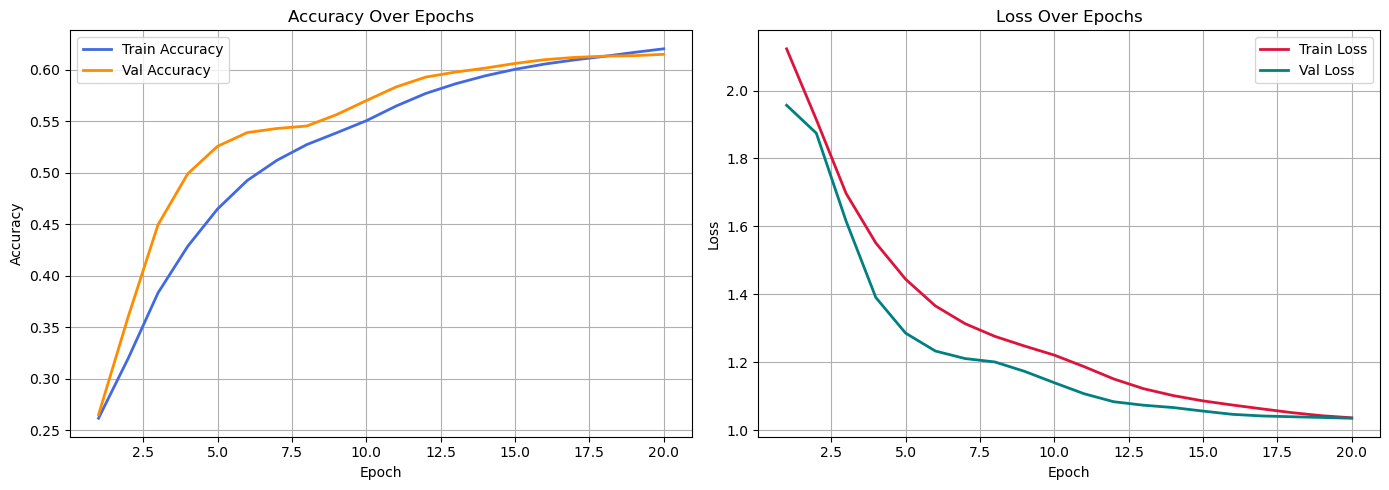

In [30]:
from scipy.ndimage import gaussian_filter1d

smooth_accuracy = gaussian_filter1d(accuracy, sigma=1)
smooth_val_accuracy = gaussian_filter1d(val_accuracy, sigma=1)
smooth_loss = gaussian_filter1d(loss, sigma=1)
smooth_val_loss = gaussian_filter1d(val_loss, sigma=1)

epochs = range(1, len(accuracy) + 1)

# Step 3: Plot
plt.figure(figsize=(14, 5))

# Accuracy graph
plt.subplot(1, 2, 1)
plt.plot(epochs, smooth_accuracy, label='Train Accuracy', color='royalblue', linewidth=2)
plt.plot(epochs, smooth_val_accuracy, label='Val Accuracy', color='darkorange', linewidth=2)
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()

# Loss graph
plt.subplot(1, 2, 2)
plt.plot(epochs, smooth_loss, label='Train Loss', color='crimson', linewidth=2)
plt.plot(epochs, smooth_val_loss, label='Val Loss', color='teal', linewidth=2)
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()



# Model Evaluation

In [32]:
# Predict class probabilities
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Classification report
print(classification_report(y_true, y_pred, target_names=class_labels))


225/225 [==============================] - 21s 89ms/step
              precision    recall  f1-score   support

       angry       0.58      0.48      0.52       958
     disgust       0.52      0.26      0.35       111
        fear       0.49      0.37      0.42      1024
       happy       0.79      0.87      0.83      1774
     neutral       0.50      0.70      0.59      1233
         sad       0.54      0.42      0.47      1247
    surprise       0.69      0.77      0.73       831

    accuracy                           0.62      7178
   macro avg       0.59      0.55      0.56      7178
weighted avg       0.61      0.62      0.61      7178



225/225 [==============================] - 19s 86ms/step


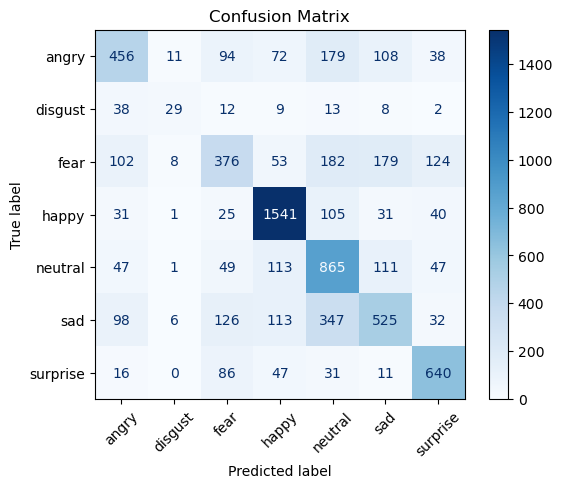

In [41]:
# Get the true labels and predicted labels for the validation set
validation_true_labels = test_generator.classes
validation_pred_probs = model.predict(test_generator)
validation_pred_labels = np.argmax(validation_pred_probs, axis=1)

# Compute the confusion matrix
matrix = confusion_matrix(validation_true_labels, validation_pred_labels)
class_labels = list(train_generator.class_indices.keys())
disp = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=class_labels)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title('Confusion Matrix')
plt.show()

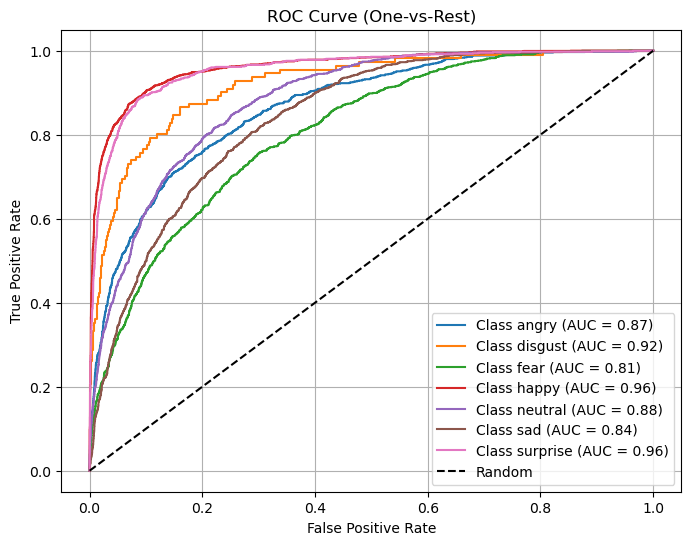

In [42]:
# Binarize the true labels for multi-class ROC
n_classes = 7
y_true_bin = label_binarize(y_true, classes=range(n_classes))

# Compute ROC curve and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot all ROC curves
plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {class_labels[i]} (AUC = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.title('ROC Curve (One-vs-Rest)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()


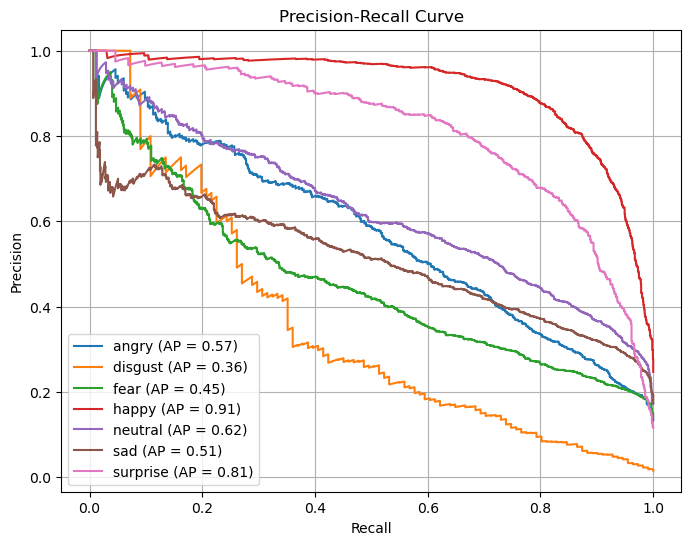

In [43]:
precision = {}
recall = {}
average_precision = {}

for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_true_bin[:, i], y_pred_probs[:, i])
    average_precision[i] = average_precision_score(y_true_bin[:, i], y_pred_probs[:, i])

plt.figure(figsize=(8, 6))
for i in range(n_classes):
    plt.plot(recall[i], precision[i], label=f'{class_labels[i]} (AP = {average_precision[i]:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()


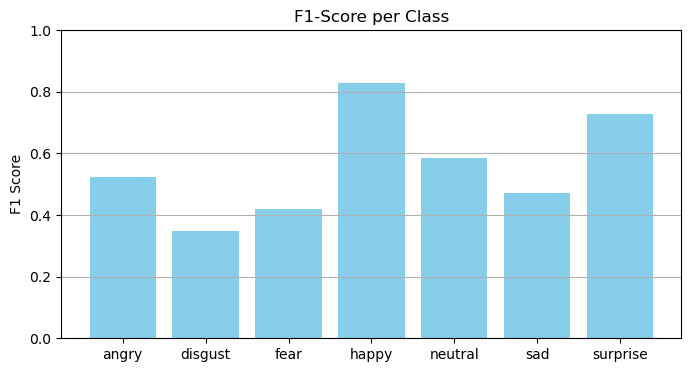

In [44]:
# Compute F1-score for each class
f1 = f1_score(y_true, y_pred, average=None)

# Plot F1-score per class
plt.figure(figsize=(8, 4))
plt.bar(class_labels, f1, color='skyblue')
plt.title('F1-Score per Class')
plt.ylabel('F1 Score')
plt.ylim([0, 1])
plt.grid(True, axis='y')
plt.show()


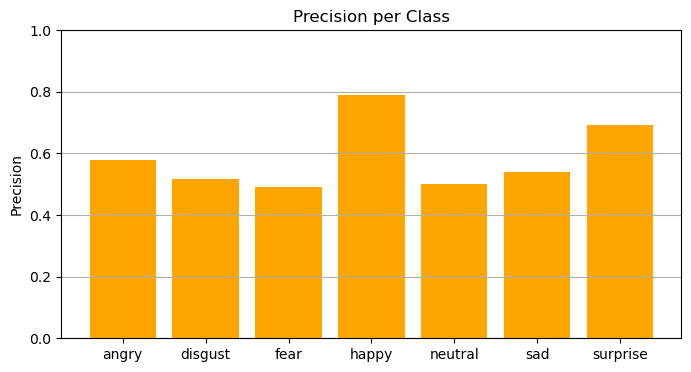

In [45]:
# Compute precision for each class
precision_scores = precision_score(y_true, y_pred, average=None)

plt.figure(figsize=(8, 4))
plt.bar(class_labels, precision_scores, color='orange')
plt.title('Precision per Class')
plt.ylabel('Precision')
plt.ylim([0, 1])
plt.grid(True, axis='y')
plt.show()


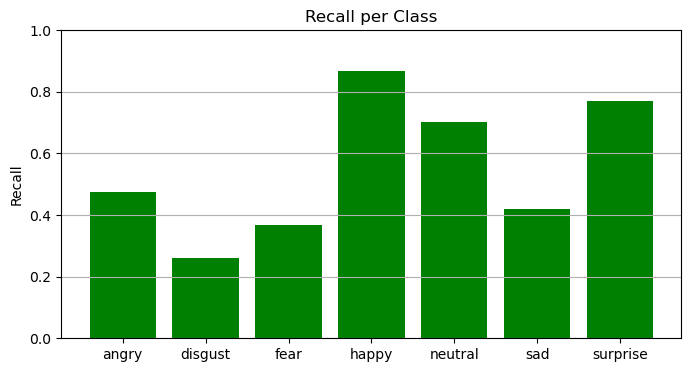

In [46]:
# Compute recall for each class
recall_scores = recall_score(y_true, y_pred, average=None)

plt.figure(figsize=(8, 4))
plt.bar(class_labels, recall_scores, color='green')
plt.title('Recall per Class')
plt.ylabel('Recall')
plt.ylim([0, 1])
plt.grid(True, axis='y')
plt.show()


1/1 [==============================] - 0s 74ms/step
Predicted: happy (26.84%)


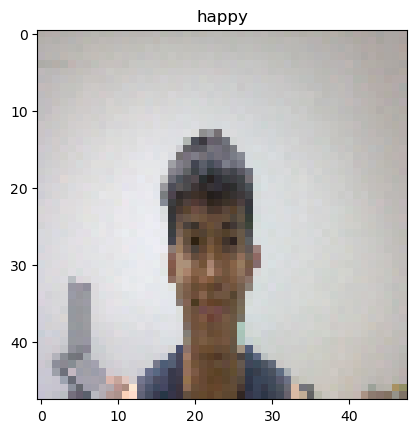

None


In [92]:
def predict_emotion(image_path):
    img = cv2.imread(image_path)
    img = cv2.resize(img, (48, 48))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = img / 255.0
    img = np.expand_dims(img, axis=0)
    pred = model.predict(img)
    class_idx = np.argmax(pred)
    print(f"Predicted: {class_labels[class_idx]} ({pred[0][class_idx]*100:.2f}%)")
    plt.imshow(img[0])
    plt.title(class_labels[class_idx])
    plt.show()

image_path = r"test_happy.jpg"

print(predict_emotion(image_path))

1/1 [==============================] - 0s 65ms/step


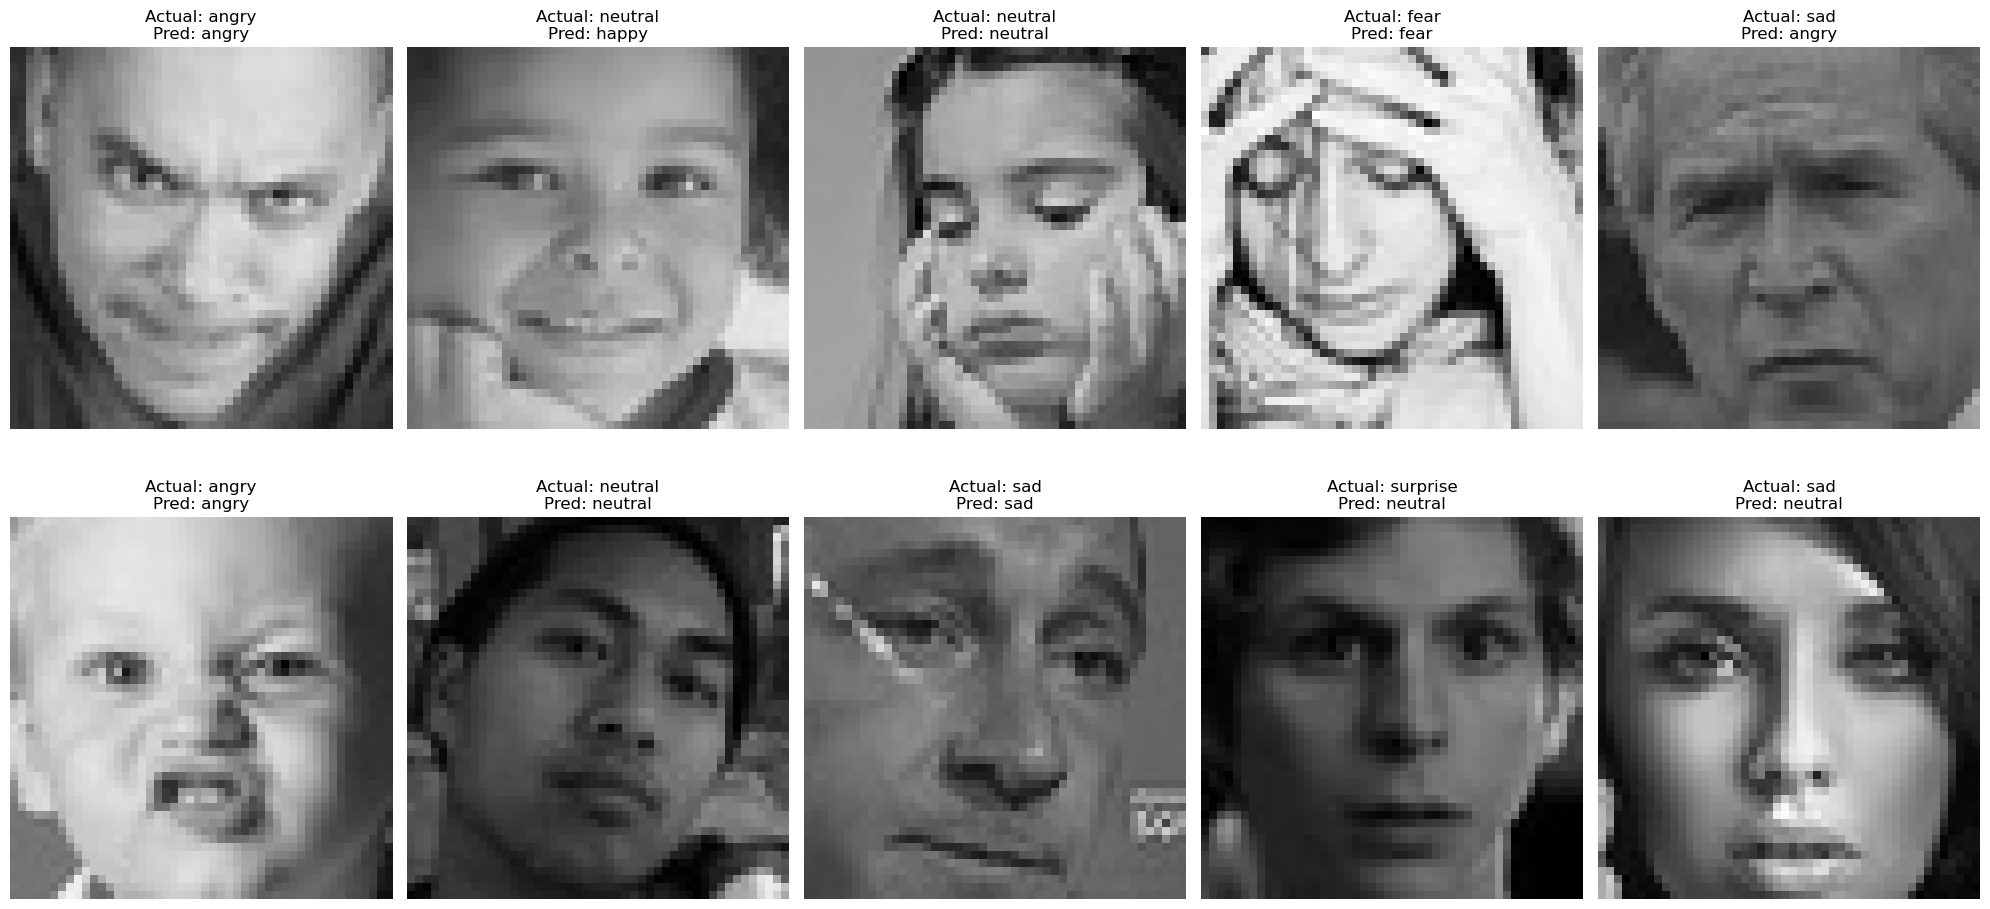

In [93]:
import random

# Number of samples to display
num_samples = 10

# Get test filepaths and corresponding true labels
filepaths = test_generator.filepaths
true_labels = test_generator.classes
class_indices = test_generator.class_indices
inv_class_indices = {v: k for k, v in class_indices.items()}

# Randomly pick indices
sample_indices = random.sample(range(len(filepaths)), num_samples)

plt.figure(figsize=(20, 10))
for i, idx in enumerate(sample_indices):
    # Load and preprocess image
    img_path = filepaths[idx]
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (48, 48))
    img_array = img_resized.astype('float32') / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    prediction = model.predict(img_array)
    predicted_label = np.argmax(prediction)
    actual_label = true_labels[idx]

    plt.subplot(2, 5, i+1)
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(f"Actual: {inv_class_indices[actual_label]}\nPred: {inv_class_indices[predicted_label]}", fontsize=12)

plt.tight_layout()
plt.show()
